# ☀️ Solar Power Output Forecasting Using Deep Learning
**Final Year B.E./B.Tech Project**

**Dataset:** Hourly Solar PV Data (Norway)

**Models:** Linear Regression, Naive Bayes, XGBoost, LSTM, Transformer (with FFN), ARIMA, SARIMA

---

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.naive_bayes import GaussianNB

from xgboost import XGBRegressor

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Input, Dense, LSTM, Dropout,
    MultiHeadAttention, LayerNormalization,
    GlobalAveragePooling1D, Conv1D, Add,
    Flatten
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

import warnings
warnings.filterwarnings("ignore")

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("=" * 60)
print("  SOLAR POWER OUTPUT FORECASTING — FINAL YEAR PROJECT")
print("=" * 60)

  SOLAR POWER OUTPUT FORECASTING — FINAL YEAR PROJECT


## 2. Load Dataset

In [2]:
print("\n[1/7] Loading dataset...")

df = pd.read_csv("Solar data.csv")

print(f"    Raw shape        : {df.shape}")
print(f"    Columns          : {list(df.columns)}")
print(f"    Missing values   :\n{df.isnull().sum()}")


[1/7] Loading dataset...
    Raw shape        : (35136, 14)
    Columns          : ['Date', 'Time', 'DateTime', 'Country', 'DC_Power', 'AC_Power', 'Ambient_Temperature', 'Module_Temperature', 'Irradiation', 'Day', 'Month', 'Hour', 'Daily_Yield', 'Total_Yield']
    Missing values   :
Date                   0
Time                   0
DateTime               0
Country                0
DC_Power               0
AC_Power               0
Ambient_Temperature    0
Module_Temperature     0
Irradiation            0
Day                    0
Month                  0
Hour                   0
Daily_Yield            0
Total_Yield            0
dtype: int64


## 3. Preprocessing

In [6]:
print("\n[2/7] Preprocessing...")

# Clean column names
df.columns = df.columns.str.strip()

print("Columns:", df.columns.tolist())

# ✅ Case 1: DateTime is already index
if isinstance(df.index, pd.DatetimeIndex):
    print("✅ DateTime already set as index")

# ✅ Case 2: DateTime exists as column
elif 'DateTime' in df.columns:
    df['DateTime'] = pd.to_datetime(df['DateTime'])
    df = df.sort_values('DateTime')
    df.set_index('DateTime', inplace=True)

# ✅ Case 3: Need to create from Date + Time
elif 'Date' in df.columns and 'Time' in df.columns:
    df['DateTime'] = pd.to_datetime(
        df['Date'].astype(str) + ' ' +
        df['Time'].astype(str).str.zfill(2) + ':00:00'
    )
    df = df.sort_values('DateTime')
    df.set_index('DateTime', inplace=True)

else:
    raise ValueError("❌ No valid DateTime information found")

# Drop safely
df.drop(columns=['Date', 'Time', 'Country'], errors='ignore', inplace=True)

# Remove duplicates
df = df[~df.index.duplicated(keep='first')]

# Ensure hourly continuity
full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='h')
df = df.reindex(full_range)
df.index.name = 'DateTime'

# Fill missing
df = df.ffill().bfill()

# Fix sensor issues
if 'Irradiation' in df.columns:
    df['Irradiation'] = df['Irradiation'].clip(lower=0)

for col in ['AC_Power', 'DC_Power']:
    if col in df.columns:
        df[col] = df[col].clip(lower=0)

# Outlier handling
Q1 = df['AC_Power'].quantile(0.25)
Q3 = df['AC_Power'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 3 * IQR

df['AC_Power'] = df['AC_Power'].clip(upper=upper_bound)

print(f"    Cleaned shape    : {df.shape}")
print(f"    Missing values   : {df.isna().sum().sum()}")


[2/7] Preprocessing...
Columns: ['DC_Power', 'AC_Power', 'Ambient_Temperature', 'Module_Temperature', 'Irradiation', 'Day', 'Month', 'Hour', 'Daily_Yield', 'Total_Yield']
✅ DateTime already set as index
    Cleaned shape    : (8784, 10)
    Missing values   : 0


## 4. Feature Engineering

In [7]:
print("\n[3/7] Engineering features...")

# --- Temporal features ---
df['Hour']        = df.index.hour
df['DayOfWeek']   = df.index.dayofweek
df['Month']       = df.index.month
df['DayOfYear']   = df.index.dayofyear
df['WeekOfYear']  = df.index.isocalendar().week.astype(int)

# --- Cyclical encoding (avoids discontinuity at 23→0, Dec→Jan) ---
df['Hour_sin']    = np.sin(2 * np.pi * df['Hour'] / 24)
df['Hour_cos']    = np.cos(2 * np.pi * df['Hour'] / 24)
df['Month_sin']   = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos']   = np.cos(2 * np.pi * df['Month'] / 12)
df['DOY_sin']     = np.sin(2 * np.pi * df['DayOfYear'] / 365)
df['DOY_cos']     = np.cos(2 * np.pi * df['DayOfYear'] / 365)

# --- Solar-physics-inspired interaction feature ---
if 'Irradiation' in df.columns and 'Module_Temperature' in df.columns:
    # PV efficiency drops with temperature; encode interaction
    df['Irrad_x_Temp'] = df['Irradiation'] * (1 - 0.004 * df['Module_Temperature'])

# --- Lag features (previous-hour context) ---
for lag in [1, 2, 3, 6, 12, 24]:
    df[f'AC_lag_{lag}'] = df['AC_Power'].shift(lag)

# --- Rolling statistics (trend & volatility) ---
for window in [3, 6, 12, 24]:
    df[f'roll_mean_{window}'] = df['AC_Power'].shift(1).rolling(window).mean()
    df[f'roll_std_{window}']  = df['AC_Power'].shift(1).rolling(window).std()

# --- Exponential weighted mean (more recent = more weight) ---
df['ewm_6']  = df['AC_Power'].shift(1).ewm(span=6).mean()
df['ewm_24'] = df['AC_Power'].shift(1).ewm(span=24).mean()

# Drop rows with NaN from lag/rolling operations
df.dropna(inplace=True)

print(f"    Features created : {df.shape[1]} columns")
print(f"    Final shape      : {df.shape}")


[3/7] Engineering features...
    Features created : 36 columns
    Final shape      : (8760, 36)


## 5. Train / Test Split (Chronological — No Shuffle)

In [8]:
print("\n[4/7] Splitting data (80/20 chronological)...")

TARGET = 'AC_Power'
DROP_COLS = [TARGET, 'DC_Power', 'Daily_Yield', 'Total_Yield']  # avoid leakage
DROP_COLS = [c for c in DROP_COLS if c in df.columns]

X = df.drop(columns=DROP_COLS)
y = df[TARGET]

split = int(len(df) * 0.80)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f"    Train samples    : {len(X_train)}")
print(f"    Test  samples    : {len(X_test)}")


[4/7] Splitting data (80/20 chronological)...
    Train samples    : 7008
    Test  samples    : 1752


## 6. Scaling

In [9]:
print("\n[5/7] Scaling features...")

feat_scaler   = MinMaxScaler()
target_scaler = MinMaxScaler()

X_train_sc = feat_scaler.fit_transform(X_train)
X_test_sc  = feat_scaler.transform(X_test)

y_train_sc = target_scaler.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_sc  = target_scaler.transform(y_test.values.reshape(-1, 1)).ravel()


[5/7] Scaling features...


## 7. Helper Functions (Sequence Builder & Metrics)

In [10]:
def build_sequences(X, y, steps=24):
    """Convert flat feature array into (samples, steps, features) sequences."""
    Xs, ys = [], []
    for i in range(len(X) - steps):
        Xs.append(X[i : i + steps])
        ys.append(y[i + steps])
    return np.array(Xs), np.array(ys)

TIME_STEPS  = 24   # 24-hour look-back window
N_FEATURES  = X_train_sc.shape[1]

X_tr_seq, y_tr_seq = build_sequences(X_train_sc, y_train_sc, TIME_STEPS)
X_te_seq, y_te_seq = build_sequences(X_test_sc,  y_test_sc,  TIME_STEPS)

# Corresponding original-scale targets for seq models
y_test_seq_orig = target_scaler.inverse_transform(
    y_te_seq.reshape(-1, 1)
).ravel()

# ── Metric helper ──
results = []

def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    results.append([name, round(mae, 4), round(rmse, 4), round(r2, 4)])
    print(f"    [{name}]  MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}")

print("\n[6/7] Training & evaluating models...\n")


[6/7] Training & evaluating models...



## 8. Model 1 — Linear Regression (Baseline)

In [11]:
print("  ── Linear Regression")
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
pred_lr = lr.predict(X_test_sc)
evaluate("Linear Regression", y_test, pred_lr)

  ── Linear Regression
    [Linear Regression]  MAE=2.9491  RMSE=4.4774  R²=0.9512


## 9. Model 2 — Gaussian Naive Bayes
> Regression proxy: quantise target into bins

In [12]:
print("  ── Naive Bayes")
N_BINS = 50
y_train_binned = pd.cut(y_train, bins=N_BINS, labels=False).fillna(0).astype(int)
bin_means = y_train.groupby(y_train_binned.values).mean()

nb = GaussianNB()
nb.fit(X_train_sc, y_train_binned)
pred_nb_bins = nb.predict(X_test_sc)
pred_nb = np.array([bin_means.get(b, bin_means.mean()) for b in pred_nb_bins])
evaluate("Naive Bayes", y_test, pred_nb)

  ── Naive Bayes
    [Naive Bayes]  MAE=3.3651  RMSE=7.2784  R²=0.8712


## 10. Model 3 — XGBoost

In [13]:
print("  ── XGBoost")
xgb = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=30,
    eval_metric='rmse',
    verbosity=0,
    random_state=42
)
xgb.fit(
    X_train_sc, y_train,
    eval_set=[(X_test_sc, y_test)],
    verbose=False
)
pred_xgb = xgb.predict(X_test_sc)
evaluate("XGBoost", y_test, pred_xgb)

  ── XGBoost
    [XGBoost]  MAE=1.2075  RMSE=2.2404  R²=0.9878


## 11. Model 4 — LSTM (Stacked, with Dropout)

In [14]:
print("  ── LSTM (Stacked)")

lstm_model = Sequential([
    LSTM(128, return_sequences=True,
         input_shape=(TIME_STEPS, N_FEATURES)),
    Dropout(0.2),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dense(16, activation='relu'),
    Dense(1)
], name="Stacked_LSTM")

lstm_model.compile(optimizer=Adam(1e-3), loss='mse', metrics=['mae'])

callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True),
    ReduceLROnPlateau(patience=5, factor=0.5)
]

lstm_model.fit(
    X_tr_seq, y_tr_seq,
    epochs=100,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

pred_lstm_sc = lstm_model.predict(X_te_seq, verbose=0).ravel()
pred_lstm = target_scaler.inverse_transform(pred_lstm_sc.reshape(-1, 1)).ravel()
evaluate("LSTM", y_test_seq_orig, pred_lstm)

  ── LSTM (Stacked)
Epoch 1/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.0168 - mae: 0.0791 - val_loss: 0.0043 - val_mae: 0.0403 - learning_rate: 0.0010
Epoch 2/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0061 - mae: 0.0493 - val_loss: 0.0042 - val_mae: 0.0398 - learning_rate: 0.0010
Epoch 3/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0059 - mae: 0.0488 - val_loss: 0.0045 - val_mae: 0.0413 - learning_rate: 0.0010
Epoch 4/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0057 - mae: 0.0473 - val_loss: 0.0045 - val_mae: 0.0413 - learning_rate: 0.0010
Epoch 5/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0056 - mae: 0.0466 - val_loss: 0.0044 - val_mae: 0.0414 - learning_rate: 0.0010
Epoch 6/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0056 - mae: 0.0463 - val_loss: 0.0044 - val_mae: 0.0409 - learning_rate: 0.0010
Epoch 7/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0053 - mae: 0.0455 - val_loss: 0.0039 - val_mae: 0.0404 - learning

## 12. Model 5 — Transformer (Multi-Head Attention + FFN)

**Architecture:**
```
Input → Conv1D Embedding
  → N × [Multi-Head Self-Attention → Add & Norm
          → Feed-Forward Network   → Add & Norm]
→ Global Average Pooling
→ MLP Head → Output
```

In [15]:
print("  ── Transformer (MHA + FFN)")

def transformer_encoder_block(x, num_heads, key_dim, ff_dim, dropout_rate=0.1):
    """
    One Transformer encoder block:
      1. Multi-Head Self-Attention  (with residual + LayerNorm)
      2. Feed-Forward Network (Dense→ReLU→Dense) (with residual + LayerNorm)
    """
    # --- Multi-Head Self-Attention ---
    attn_out = MultiHeadAttention(
        num_heads=num_heads, key_dim=key_dim, dropout=dropout_rate
    )(x, x)
    attn_out = Dropout(dropout_rate)(attn_out)
    x = LayerNormalization(epsilon=1e-6)(Add()([x, attn_out]))   # residual

    # --- Position-wise Feed-Forward Network (FFN) ---
    ffn = Dense(ff_dim, activation='gelu')(x)   # GELU: smooth non-linearity
    ffn = Dropout(dropout_rate)(ffn)
    ffn = Dense(x.shape[-1])(ffn)               # project back to model dim
    ffn = Dropout(dropout_rate)(ffn)
    x = LayerNormalization(epsilon=1e-6)(Add()([x, ffn]))         # residual

    return x


def build_transformer(
    seq_len, n_features,
    d_model=64,        # model (embedding) dimension
    num_heads=4,       # attention heads
    ff_dim=128,        # FFN hidden units
    num_blocks=3,      # stacked encoder blocks
    mlp_units=None,    # MLP head units
    dropout=0.1
):
    if mlp_units is None:
        mlp_units = [64, 32]

    inp = Input(shape=(seq_len, n_features), name="sequence_input")

    # Linear projection: map raw features → d_model dimensional space
    x = Conv1D(filters=d_model, kernel_size=1, padding='same', name="input_projection")(inp)

    # Stack Transformer encoder blocks
    for i in range(num_blocks):
        x = transformer_encoder_block(
            x,
            num_heads=num_heads,
            key_dim=d_model // num_heads,
            ff_dim=ff_dim,
            dropout_rate=dropout
        )

    # Aggregate sequence → single vector
    x = GlobalAveragePooling1D(name="global_avg_pool")(x)

    # MLP prediction head
    for units in mlp_units:
        x = Dense(units, activation='relu')(x)
        x = Dropout(dropout)(x)

    output = Dense(1, name="forecast_output")(x)

    model = Model(inputs=inp, outputs=output, name="Transformer_Forecaster")
    return model


transformer_model = build_transformer(
    seq_len=TIME_STEPS,
    n_features=N_FEATURES,
    d_model=64,
    num_heads=4,
    ff_dim=128,
    num_blocks=3,
    mlp_units=[64, 32],
    dropout=0.1
)

transformer_model.compile(optimizer=Adam(5e-4), loss='mse', metrics=['mae'])
transformer_model.summary()

transformer_model.fit(
    X_tr_seq, y_tr_seq,
    epochs=100,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

pred_tf_sc  = transformer_model.predict(X_te_seq, verbose=0).ravel()
pred_tf     = target_scaler.inverse_transform(pred_tf_sc.reshape(-1, 1)).ravel()
evaluate("Transformer (MHA+FFN)", y_test_seq_orig, pred_tf)

  ── Transformer (MHA + FFN)


Model: "Transformer_Forecaster"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 24, 32)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_projection    │ (None, 24, 64)    │      2,112 │ sequence_input[0… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 24, 64)    │     16,640 │ input_projection… │
│ (MultiHeadAttentio… │                   │            │ input_projection… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 24, 64)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 24, 64)    │          0 │ input_projection… │
│                     │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 24, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 24, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 24, 128)   │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 24, 64)    │      8,256 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 24, 64)    │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 24, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 24, 64)    │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 24, 64)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 24, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 64)    │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 24, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 24, 128)   │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 24, 64)    │      8,256 │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 24, 64)    │          0 │ dense_5[0][0]   

 Total params: 108,801 (425.00 KB)

 Trainable params: 108,801 (425.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.1007 - mae: 0.2629 - val_loss: 0.0838 - val_mae: 0.2406 - learning_rate: 5.0000e-04
Epoch 2/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0859 - mae: 0.2496 - val_loss: 0.0836 - val_mae: 0.2432 - learning_rate: 5.0000e-04
Epoch 3/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0849 - mae: 0.2502 - val_loss: 0.0830 - val_mae: 0.2431 - learning_rate: 5.0000e-04
Epoch 4/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0836 - mae: 0.2495 - val_loss: 0.0827 - val_mae: 0.2553 - learning_rate: 5.0000e-04
Epoch 5/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0840 - mae: 0.2493 - val_loss: 0.0824 - val_mae: 0.2456 - learning_rate: 5.0000e-04
Epoch 6/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0834 - mae: 0.2487 - val_loss: 0.0824 - val_mae: 0.2462 - learning_rate: 2.5000e-04
Epoch 7/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0824 - mae: 0.2485 - val_loss: 0.0823 - val_mae: 0.2475 - lear

## 13. Model 6 — ARIMA

In [16]:
print("  ── ARIMA (5,1,0)")

arima_model = ARIMA(y_train, order=(5, 1, 0)).fit()
pred_arima  = arima_model.forecast(steps=len(y_test))
evaluate("ARIMA", y_test, pred_arima)

  ── ARIMA (5,1,0)
    [ARIMA]  MAE=15.7323  RMSE=25.6649  R²=-0.6019


## 14. Model 7 — SARIMA

In [17]:
print("  ── SARIMA (1,1,1)(1,1,1,24)")

sarima_model = SARIMAX(
    y_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

pred_sarima = sarima_model.forecast(steps=len(y_test))
evaluate("SARIMA", y_test, pred_sarima)

  ── SARIMA (1,1,1)(1,1,1,24)
    [SARIMA]  MAE=4.8984  RMSE=8.0825  R²=0.8411


## 15. Results Table

In [19]:
print("\n[7/7] Final Results\n")

results_df = pd.DataFrame(
    results, columns=["Model", "MAE (kW)", "RMSE (kW)", "R² Score"]
).sort_values("R² Score", ascending=False).reset_index(drop=True)

results_df.index += 1   # rank from 1

print("=" * 65)
print(results_df.to_string())
print("=" * 65)

best = results_df.iloc[0]
print(f"\n🏆  BEST MODEL : {best['Model']}")
print(f"    MAE        : {best['MAE (kW)']} kW")
print(f"    RMSE       : {best['RMSE (kW)']} kW")
print(f"    R² Score   : {best['R² Score']}")

# Display as styled table in notebook
results_df.style.background_gradient(cmap='RdYlGn', subset=['R² Score']) \
               .background_gradient(cmap='RdYlGn_r', subset=['MAE (kW)', 'RMSE (kW)']) \
               .set_caption("Model Performance Summary")


[7/7] Final Results

                   Model  MAE (kW)  RMSE (kW)  R² Score
1                XGBoost    1.2075     2.2404    0.9878
2      Linear Regression    2.9491     4.4774    0.9512
3            Naive Bayes    3.3651     7.2784    0.8712
4                 SARIMA    4.8984     8.0825    0.8411
5                   LSTM    4.9877     8.1877    0.8370
6  Transformer (MHA+FFN)   16.7746    20.4109   -0.0128
7                  ARIMA   15.7323    25.6649   -0.6019

🏆  BEST MODEL : XGBoost
    MAE        : 1.2075 kW
    RMSE       : 2.2404 kW
    R² Score   : 0.9878


,Model,MAE (kW),RMSE (kW),R² Score
1,XGBoost,1.207500,2.240400,0.987800
2,Linear Regression,2.949100,4.477400,0.951200
3,Naive Bayes,3.365100,7.278400,0.871200
4,SARIMA,4.898400,8.082500,0.841100
5,LSTM,4.987700,8.187700,0.837000
6,Transformer (MHA+FFN),16.774600,20.410900,-0.012800
7,ARIMA,15.732300,25.664900,-0.601900


## 16. Visualisations

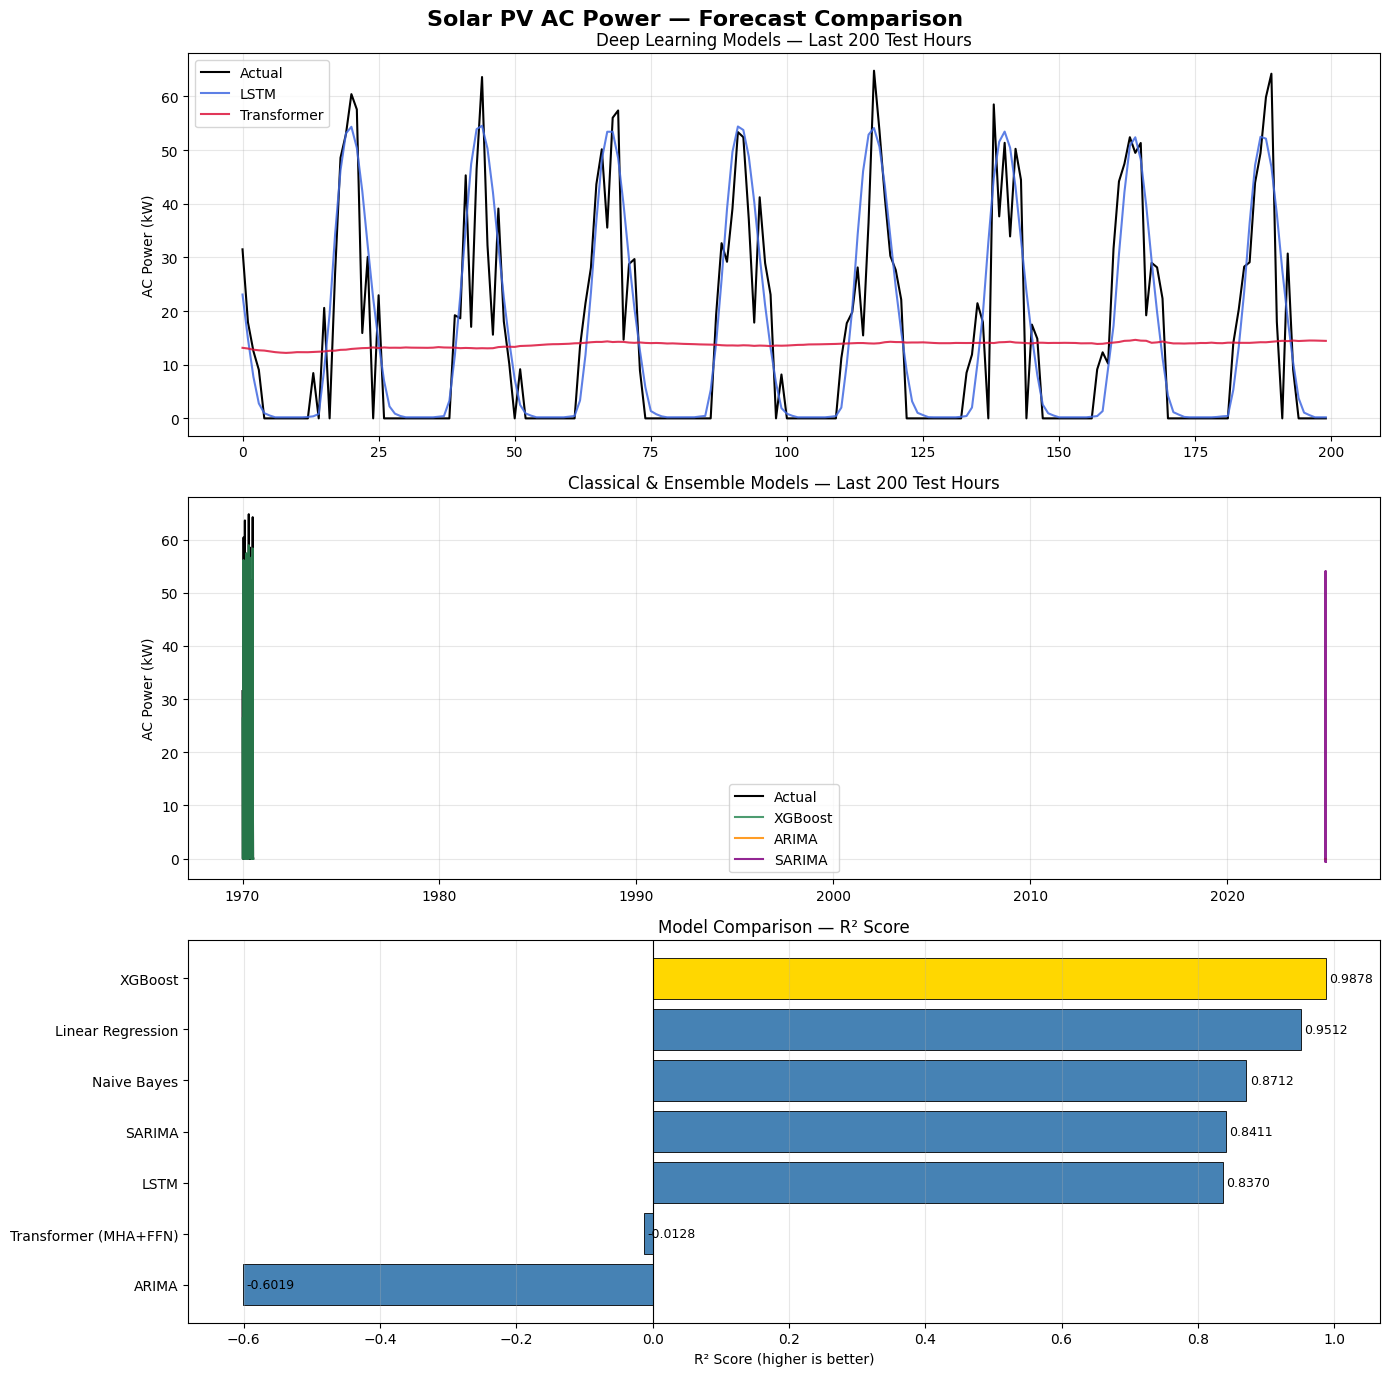


  Chart saved → model_comparison.png

✅  Pipeline complete.



In [20]:
fig, axes = plt.subplots(3, 1, figsize=(14, 14))
fig.suptitle("Solar PV AC Power — Forecast Comparison", fontsize=16, fontweight='bold')

# ── Plot 1: LSTM vs Actual (last 200 hours)
ax = axes[0]
ax.plot(y_test_seq_orig[-200:], label='Actual',    color='black',  linewidth=1.5)
ax.plot(pred_lstm[-200:],       label='LSTM',      color='royalblue', alpha=0.85)
ax.plot(pred_tf[-200:],         label='Transformer', color='crimson', alpha=0.85)
ax.set_title("Deep Learning Models — Last 200 Test Hours")
ax.set_ylabel("AC Power (kW)")
ax.legend(); ax.grid(alpha=0.3)

# ── Plot 2: Classical models vs Actual (last 200 hours)
ax = axes[1]
ax.plot(y_test.values[-200:],  label='Actual', color='black', linewidth=1.5)
ax.plot(pred_xgb[-200:],       label='XGBoost', color='seagreen', alpha=0.85)
ax.plot(pred_arima[-200:],     label='ARIMA',   color='darkorange', alpha=0.85)
ax.plot(pred_sarima[-200:],    label='SARIMA',  color='purple', alpha=0.85)
ax.set_title("Classical & Ensemble Models — Last 200 Test Hours")
ax.set_ylabel("AC Power (kW)")
ax.legend(); ax.grid(alpha=0.3)

# ── Plot 3: Model comparison bar chart (R²)
ax = axes[2]
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(results_df))]
bars = ax.barh(results_df["Model"][::-1], results_df["R² Score"][::-1],
               color=colors[::-1], edgecolor='k', linewidth=0.6)
ax.set_xlabel("R² Score (higher is better)")
ax.set_title("Model Comparison — R² Score")
ax.axvline(0, color='k', linewidth=0.8)
for bar, val in zip(bars, results_df["R² Score"][::-1]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n  Chart saved → model_comparison.png")
print("\n✅  Pipeline complete.\n")